# Example Sparse Matrix Surface

Canonical sparse/block-sparse example notebook for the sparse matrix tranche.

## Scope

This notebook is the canonical example surface for `example_sparse_matrix_surface`. It runs against the repo source tree through `/src`, shows direct public API usage, summarizes validation and benchmark status, and includes visual summaries.

In [1]:
import io
import json
import os
import re
import subprocess
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'arbplusjax').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from: {start}')

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
os.chdir(REPO_ROOT)

PYTHON = os.getenv('ARBPLUSJAX_PYTHON', sys.executable)
JAX_MODE = os.getenv('JAX_MODE', 'cpu').strip().lower()
JAX_DTYPE = os.getenv('JAX_DTYPE', 'float64').strip().lower()
RUN_ENV = os.environ.copy()
RUN_ENV['PYTHONPATH'] = str(REPO_ROOT / 'src') + os.pathsep + RUN_ENV.get('PYTHONPATH', '')
if JAX_MODE == 'cpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cpu'
elif JAX_MODE == 'gpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cuda'
RUN_ENV['JAX_ENABLE_X64'] = '1' if JAX_DTYPE == 'float64' else '0'
EXAMPLE_INPUT_ROOT = REPO_ROOT / 'examples' / 'inputs' / 'example_sparse_matrix_surface'
EXAMPLE_OUTPUT_ROOT = REPO_ROOT / 'examples' / 'outputs' / 'example_sparse_matrix_surface'
EXAMPLE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def run(cmd: list[str], *, capture: bool = False):
    print('[cmd]', ' '.join(cmd))
    return subprocess.run(cmd, cwd=REPO_ROOT, env=RUN_ENV, text=True, capture_output=capture, check=True)


## Environment

The notebook reports interpreter, selected JAX mode, and the active backend/device view. Canonical retained execution in this repo state is CPU-oriented, but the notebook calling pattern remains CPU/GPU portable and explicitly parameterized for `float32` and `float64`.

In [2]:
SUPPORTED_JAX_MODES = ('cpu', 'gpu')
SUPPORTED_JAX_DTYPES = ('float32', 'float64')
if JAX_MODE not in SUPPORTED_JAX_MODES:
    raise ValueError(f'Unsupported JAX_MODE: {JAX_MODE}')
if JAX_DTYPE not in SUPPORTED_JAX_DTYPES:
    raise ValueError(f'Unsupported JAX_DTYPE: {JAX_DTYPE}')
print('python:', PYTHON)
print('jax_mode:', JAX_MODE)
print('jax_dtype:', JAX_DTYPE)
print('supported_jax_modes:', SUPPORTED_JAX_MODES)
print('supported_jax_dtypes:', SUPPORTED_JAX_DTYPES)
print('validation_slice:', 'cpu_current__gpu_portable_contract')
runtime = run([PYTHON, 'tools/check_jax_runtime.py'], capture=True)
print(runtime.stdout)
runtime_payload = json.loads(runtime.stdout)
(EXAMPLE_OUTPUT_ROOT / f'runtime_{JAX_MODE}.json').write_text(json.dumps(runtime_payload, indent=2) + '\n', encoding='utf-8')

python: /home/phili/miniforge3/envs/jax/bin/python
jax_mode: cpu
jax_dtype: float64
supported_jax_modes: ('cpu', 'gpu')
supported_jax_dtypes: ('float32', 'float64')
validation_slice: cpu_current__gpu_portable_contract
[cmd] /home/phili/miniforge3/envs/jax/bin/python tools/check_jax_runtime.py


{
  "platform": "cpu",
  "devices": [
    "TFRT_CPU_0"
  ],
  "jax_enable_x64": true,
  "env": {
    "JAX_PLATFORM_NAME": "",
    "XLA_PYTHON_CLIENT_PREALLOCATE": "",
    "XLA_PYTHON_CLIENT_MEM_FRACTION": "",
    "XLA_FLAGS": ""
  }
}



235

## Direct Usage

Construct sparse real/complex operators and exercise the public sparse API surface.

In [3]:
import jax
import jax.numpy as jnp
from arbplusjax import api, scb_mat, srb_mat

dense_real = jnp.array([[4.0, 1.0, 0.0], [1.0, 5.0, 2.0], [0.0, 2.0, 6.0]], dtype=jnp.float64)
dense_complex = dense_real + 1j * jnp.array([[0.0, 0.2, 0.0], [-0.2, 0.0, 0.1], [0.0, -0.1, 0.0]], dtype=jnp.float64)
sparse_real = srb_mat.srb_mat_from_dense_bcoo(dense_real)
sparse_complex = scb_mat.scb_mat_from_dense_bcoo(dense_complex)
block_real = api.eval_point('srb_block_mat_from_dense_csr', dense_real, block_shape=(1, 1))
vblock_real = api.eval_point('srb_vblock_mat_from_dense_csr', dense_real, row_block_sizes=jnp.asarray([1, 2], dtype=jnp.int32), col_block_sizes=jnp.asarray([1, 2], dtype=jnp.int32))
vec_real = jnp.stack([jnp.array([1.0, 0.5, -0.25], dtype=jnp.float64), jnp.array([0.25, -0.5, 1.0], dtype=jnp.float64)], axis=0)
vec_complex = jnp.stack([
    jnp.array([1.0 + 0.2j, 0.5 - 0.1j, -0.25 + 0.3j], dtype=jnp.complex128),
    jnp.array([0.25 - 0.1j, -0.5 + 0.2j, 1.0 + 0.0j], dtype=jnp.complex128),
], axis=0)
real_plan = api.eval_point('srb_mat_matvec_cached_prepare', sparse_real)
complex_plan = api.eval_point('scb_mat_matvec_cached_prepare', sparse_complex)
real_rplan = api.eval_point('srb_mat_rmatvec_cached_prepare', sparse_real)
sparse_results = {
    'srb_matvec': api.eval_point_batch('srb_mat_matvec', sparse_real, vec_real),
    'srb_cached_matvec': jax.vmap(lambda row: api.eval_point('srb_mat_matvec_cached_apply', real_plan, row))(vec_real),
    'srb_cached_rmatvec': jax.vmap(lambda row: api.eval_point('srb_mat_rmatvec_cached_apply', real_rplan, row))(vec_real),
    'srb_block_matvec': api.eval_point_batch('srb_block_mat_matvec', block_real, vec_real),
    'srb_vblock_matvec': api.eval_point_batch('srb_vblock_mat_matvec', vblock_real, vec_real),
    'scb_matvec': api.eval_point_batch('scb_mat_matvec', sparse_complex, vec_complex),
    'scb_cached_matvec': jax.vmap(lambda row: api.eval_point('scb_mat_matvec_cached_apply', complex_plan, row))(vec_complex),
}
display(sparse_results)

{'srb_matvec': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64),
 'srb_cached_matvec': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64),
 'srb_cached_rmatvec': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64),
 'srb_block_matvec': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64),
 'srb_vblock_matvec': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64),
 'scb_matvec': Array([[ 4.52+0.8j  ,  3.01+0.075j, -0.51+1.55j ],
        [ 0.46-0.3j  , -0.27+0.95j ,  5.02+0.45j ]], dtype=complex128),
 'scb_cached_matvec': Array([[ 4.52+0.8j  ,  3.01+0.075j, -0.51+1.55j ],
        [ 0.46-0.3j  , -0.27+0.95j ,  5.02+0.45j ]], dtype=complex128)}

## Production Pattern

Sparse production calls should prepare cached plans once and reuse them for repeated apply or solve traffic. If an API-facing service loop feeds variable batch sizes, pad the RHS batch to a stable multiple before calling the padded batch kernels.

In [4]:
import jax
rhs_batch = vec_real
real_cached = api.eval_point('srb_mat_matvec_cached_prepare', sparse_real)
real_rcached = api.eval_point('srb_mat_rmatvec_cached_prepare', sparse_real)
sparse_service_results = {
    'cached_apply': jax.vmap(lambda row: api.eval_point('srb_mat_matvec_cached_apply', real_cached, row))(rhs_batch),
    'cached_rmatvec': jax.vmap(lambda row: api.eval_point('srb_mat_rmatvec_cached_apply', real_rcached, row))(rhs_batch),
    'padded_batch_apply': api.eval_point_batch('srb_mat_matvec', sparse_real, rhs_batch, pad_to=8),
    'block_sparse_apply': api.eval_point_batch('srb_block_mat_matvec', block_real, rhs_batch),
    'vblock_sparse_apply': api.eval_point_batch('srb_vblock_mat_matvec', vblock_real, rhs_batch),
}
display(sparse_service_results)

{'cached_apply': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64),
 'cached_rmatvec': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64),
 'padded_batch_apply': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64),
 'block_sparse_apply': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64),
 'vblock_sparse_apply': Array([[ 4.5 ,  3.  , -0.5 ],
        [ 0.5 , -0.25,  5.  ]], dtype=float64)}

## Extending Benchmarks

To extend sparse benchmarks, add the target sparse/storage/mode combination inside `benchmark_sparse_matrix_surface.py` and keep the printed metric keys stable so downstream notebook parsing still works.

## Fast JAX Point Pattern

Sparse point-mode fast JAX should use the compiled batch binder on a prepared operator or cached plan, with shape-stable RHS batches.

In [5]:
import jax
sparse_fast = api.bind_point_batch_jit('srb_mat_matvec_cached_apply', dtype='float64', pad_to=4)
sparse_fast_out = sparse_fast(real_cached, rhs_batch)
sparse_vmap = jax.vmap(lambda row: api.eval_point('srb_mat_matvec_cached_apply', real_cached, row, dtype='float64'))(rhs_batch)
display({'jit_shape': sparse_fast_out.shape, 'jit_matches_vmap': bool(jnp.allclose(sparse_fast_out, sparse_vmap))})

{'jit_shape': (2, 3), 'jit_matches_vmap': True}

## AD Product Pattern

Sparse AD should be demonstrated in both directions through stable public operations that are realistically differentiated in downstream models. This section differentiates sparse matvec over both the input vector and a matrix scale parameter, then plots the paired sensitivities.

,vec_entry,primal_vec,grad_vec,scale,primal_scale,grad_scale
0,-0.750000,8.062500,-17.500000,0.500000,7.375000,29.500000
1,-0.684783,6.993502,-15.282609,0.543478,8.713374,32.065217
2,-0.619565,6.069116,-13.065217,0.586957,10.163280,34.630435
3,-0.554348,5.289343,-10.847826,0.630435,11.724716,37.195652
4,-0.489130,4.654182,-8.630435,0.673913,13.397684,39.760870


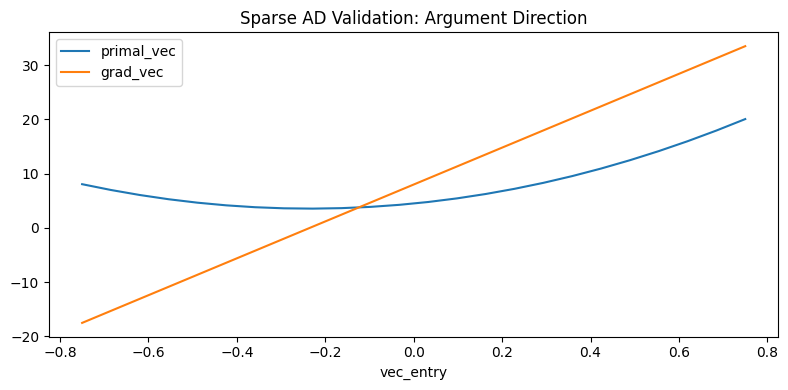

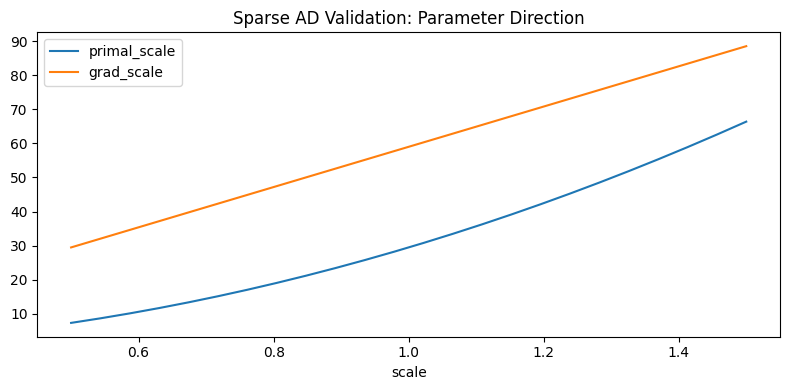

In [6]:
import jax
dense_param = jnp.array([[4.0, 1.0, 0.0], [1.0, 5.0, 2.0], [0.0, 2.0, 6.0]], dtype=jnp.float64)
vec_fixed = jnp.array([1.0, 0.5, -0.25], dtype=jnp.float64)
def sparse_loss_vec(v):
    sparse_fixed = srb_mat.srb_mat_from_dense_bcoo(dense_param)
    out = api.eval_point('srb_mat_matvec', sparse_fixed, v)
    return jnp.sum(out ** 2)
def sparse_loss_scale(scale):
    sparse_scaled = srb_mat.srb_mat_from_dense_bcoo(scale * dense_param)
    out = api.eval_point('srb_mat_matvec', sparse_scaled, vec_fixed)
    return jnp.sum(out ** 2)
vec_sweep = jnp.linspace(-0.75, 0.75, 24, dtype=jnp.float64)
scale_sweep = jnp.linspace(0.5, 1.5, 24, dtype=jnp.float64)
primal_vec = jax.vmap(lambda t: sparse_loss_vec(jnp.asarray([t, vec_fixed[1], vec_fixed[2]], dtype=jnp.float64)))(vec_sweep)
grad_vec = jax.vmap(lambda t: jax.grad(sparse_loss_vec)(jnp.asarray([t, vec_fixed[1], vec_fixed[2]], dtype=jnp.float64))[0])(vec_sweep)
primal_scale = jax.vmap(sparse_loss_scale)(scale_sweep)
grad_scale = jax.vmap(jax.grad(sparse_loss_scale))(scale_sweep)
ad_df = pd.DataFrame({'vec_entry': np.asarray(vec_sweep), 'primal_vec': np.asarray(primal_vec), 'grad_vec': np.asarray(grad_vec), 'scale': np.asarray(scale_sweep), 'primal_scale': np.asarray(primal_scale), 'grad_scale': np.asarray(grad_scale)})
display(ad_df.head())
ax = ad_df.plot(x='vec_entry', y=['primal_vec', 'grad_vec'], figsize=(8, 4), title='Sparse AD Validation: Argument Direction')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'ad_validation_argument_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()
ax = ad_df.plot(x='scale', y=['primal_scale', 'grad_scale'], figsize=(8, 4), title='Sparse AD Validation: Parameter Direction')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'ad_validation_parameter_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Validation Summary

Run the sparse API and chassis tests that own this surface.

In [7]:
test_cmd = [
    PYTHON, '-m', 'pytest', '-q',
    'tests/test_sparse_point_api.py',
    'tests/test_sparse_basic_contracts.py',
    'tests/test_srb_mat_chassis.py',
    'tests/test_scb_mat_chassis.py',
    'tests/test_srb_block_mat_chassis.py',
    'tests/test_scb_block_mat_chassis.py',
    'tests/test_srb_vblock_mat_chassis.py',
    'tests/test_scb_vblock_mat_chassis.py',
]
try:
    tests = run(test_cmd, capture=True)
    test_status = 'passed'
except subprocess.CalledProcessError as exc:
    tests = exc
    test_status = 'failed'
print(tests.stdout)
if tests.stderr:
    print(tests.stderr)
(EXAMPLE_OUTPUT_ROOT / f'pytest_{JAX_MODE}.txt').write_text((tests.stdout or '') + ('\n' + tests.stderr if tests.stderr else ''), encoding='utf-8')
display({'validation_status': test_status})

[cmd] /home/phili/miniforge3/envs/jax/bin/python -m pytest -q tests/test_sparse_point_api.py tests/test_sparse_basic_contracts.py tests/test_srb_mat_chassis.py tests/test_scb_mat_chassis.py tests/test_srb_block_mat_chassis.py tests/test_scb_block_mat_chassis.py tests/test_srb_vblock_mat_chassis.py tests/test_scb_vblock_mat_chassis.py


...........................F...F..F...F.                                 [100%]
=================================== FAILURES ===================================
_______________ test_block_sparse_real_basic_det_inv_and_square ________________

    def test_block_sparse_real_basic_det_inv_and_square():
        dense = jnp.array(
            [
                [4.0, 1.0, 0.0, 0.0],
                [1.0, 5.0, 0.5, 0.0],
                [0.0, 0.5, 3.5, 1.0],
                [0.0, 0.0, 1.0, 2.5],
            ],
            dtype=jnp.float64,
        )
        csr = srb_block_mat.srb_block_mat_from_dense_csr(dense, block_shape=(2, 2))
    
        det_basic = srb_block_mat.srb_block_mat_det_basic(csr)
        inv_basic = srb_block_mat.srb_block_mat_inv_basic(csr)
        sqr_basic = srb_block_mat.srb_block_mat_sqr_basic(csr)
    
        det_ref = jnp.linalg.det(dense)
        inv_ref = jnp.linalg.inv(dense)
        sqr_ref = dense @ dense
    
>       _check(bool(di.contains(det_basic, di.int

{'validation_status': 'failed'}

## Benchmark Summary

Run the sparse surface benchmark and convert the printed metrics into a structured table.

In [8]:
completed = run([PYTHON, 'benchmarks/benchmark_sparse_matrix_surface.py', '--n', '16', '--warmup', '1', '--runs', '2'], capture=True)
print(completed.stdout)
rows = []
for line in completed.stdout.splitlines():
    if ': ' not in line:
        continue
    key, value = line.split(': ', 1)
    if key in {'platform', 'jax'} or key.startswith('n'):
        continue
    try:
        rows.append({'metric': key, 'seconds': float(value)})
    except ValueError:
        pass
bench_df = pd.DataFrame(rows).sort_values('seconds')
bench_df.to_csv(EXAMPLE_OUTPUT_ROOT / f'sparse_benchmark_summary_{JAX_MODE}.csv', index=False)
display(bench_df.head(20))

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_sparse_matrix_surface.py --n 16 --warmup 1 --runs 2


platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
jax: 0.8.2
n: 16, warmup: 1, runs: 2, dtype: float64, smoke: False
scb_bcoo_basic_cached_matvec_s: 2.024174e-02
scb_bcoo_basic_cached_prepare_s: 2.172918e-03
scb_bcoo_basic_cached_rmatvec_s: 1.541100e-02
scb_bcoo_basic_det_s: 1.058009e-01
scb_bcoo_basic_eigsh_s: 2.447237e-01
scb_bcoo_basic_hpd_prepare_s: 9.864970e-03
scb_bcoo_basic_inv_s: 7.814340e-01
scb_bcoo_basic_lu_plan_solve_s: 1.662095e-02
scb_bcoo_basic_lu_prepare_s: 7.655813e-03
scb_bcoo_basic_mat_solve_s: 4.692720e-03
scb_bcoo_basic_matvec_s: 1.677176e-02
scb_bcoo_basic_padded_hpd_solve_s: 3.789534e-02
scb_bcoo_basic_padded_matvec_s: 1.056132e-01
scb_bcoo_basic_rmatvec_s: 1.821860e-02
scb_bcoo_basic_solve_s: 2.976589e-01
scb_bcoo_basic_sqr_s: 6.964392e-03
scb_bcoo_basic_storage_prepare_s: 2.404643e-03
scb_bcoo_basic_transpose_solve_s: 7.669467e-03
scb_bcoo_point_cached_matvec_s: 1.554865e-03
scb_bcoo_point_cached_prepare_s: 2.109550e-05
scb_bcoo_point_cache

,metric,seconds
19,scb_bcoo_point_cached_prepare_s,0.000021
163,srb_coo_point_cached_prepare_s,0.000021
127,srb_bcoo_point_cached_prepare_s,0.000030
55,scb_coo_point_cached_prepare_s,0.000031
109,srb_bcoo_basic_cached_prepare_s,0.000470
56,scb_coo_point_cached_rmatvec_s,0.000536
164,srb_coo_point_cached_rmatvec_s,0.000551
145,srb_coo_basic_cached_prepare_s,0.000558
174,srb_coo_point_rmatvec_s,0.000604
162,srb_coo_point_cached_matvec_s,0.000612


## Comparison / Contrast

Compare sparse, block-sparse, and variable-block matvec/cached-rmatvec surfaces in one place so users can see when storage structure changes the calling pattern.

In [9]:
compare_metrics = bench_df[bench_df['metric'].str.contains('matvec|rmatvec', regex=True, na=False)].copy()
display(compare_metrics.head(20))

,metric,seconds
56,scb_coo_point_cached_rmatvec_s,0.000536
164,srb_coo_point_cached_rmatvec_s,0.000551
174,srb_coo_point_rmatvec_s,0.000604
162,srb_coo_point_cached_matvec_s,0.000612
198,srb_csr_point_cached_matvec_s,0.000648
67,scb_coo_point_rmatvec_s,0.000651
54,scb_coo_point_cached_matvec_s,0.000693
90,scb_csr_point_cached_matvec_s,0.000725
92,scb_csr_point_cached_rmatvec_s,0.000765
200,srb_csr_point_cached_rmatvec_s,0.000774


## Plots

Plot the fastest sparse benchmark metrics as a compact diagnostic summary.

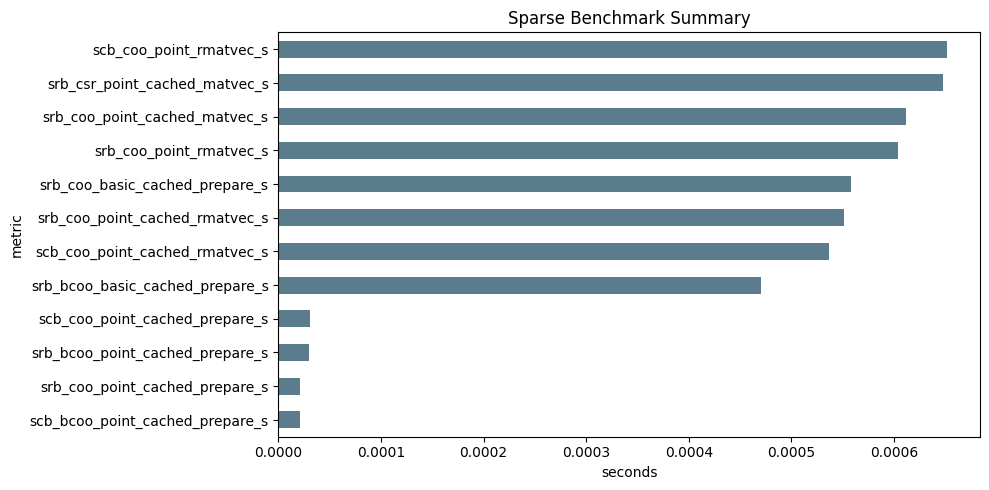

In [10]:
top = bench_df.head(12).copy()
ax = top.plot(x='metric', y='seconds', kind='barh', figsize=(10, 5), color='#5b7c8d', legend=False, title='Sparse Benchmark Summary')
ax.set_xlabel('seconds')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'sparse_benchmark_summary_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Optional Diagnostics

Detailed sparse solver/factor diagnostics remain owned by the sparse matrix modules and their dedicated benchmarks.

In [11]:
summary_lines = [
    f'# Example Sparse Matrix Surface Summary ({JAX_MODE})',
    '',
    f'- backend: `{runtime_payload["platform"]}`',
    f'- benchmark_rows: `{len(bench_df)}`',
    '',
    '## Fastest Metrics',
    '',
]
for row in top.to_dict(orient='records'):
    summary_lines.append(f"- `{row['metric']}`: {row['seconds']:.6g}s")
(EXAMPLE_OUTPUT_ROOT / f'summary_{JAX_MODE}.md').write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
display('\n'.join(summary_lines[:12]))

'# Example Sparse Matrix Surface Summary (cpu)\n\n- backend: `cpu`\n- benchmark_rows: `216`\n\n## Fastest Metrics\n\n- `scb_bcoo_point_cached_prepare_s`: 2.10955e-05s\n- `srb_coo_point_cached_prepare_s`: 2.14565e-05s\n- `srb_bcoo_point_cached_prepare_s`: 2.975e-05s\n- `scb_coo_point_cached_prepare_s`: 3.12065e-05s\n- `srb_bcoo_basic_cached_prepare_s`: 0.000470023s'